# Notebook 01: Labor Market Intelligence
**Data Source:** Bureau of Labor Statistics (BLS) Local Area Unemployment Statistics (LAUS) — Washington, D.C. (2019–2024)
**Records:** 72 monthly observations (wide format)
**Metrics:** Unemployment Rate (%), Employment Level (thousands)

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

BASE = Path('/root/.openclaw/workspace/sierra-pmo-analytics/projects/executive-decision-support')
df = pd.read_csv(BASE / 'data/bls_dc_wide.csv')
df['date'] = pd.to_datetime(df['year'].astype(str) + '-' + df['period'].str.replace('M', '') + '-01')
df = df.sort_values('date').reset_index(drop=True)
print(f"Records: {len(df)} | Date range: {df['date'].min().date()} to {df['date'].max().date()}")
df.head()

Records: 72 | Date range: 2019-01-01 to 2024-12-01


,year,period,dc_employment_level,dc_unemployment_rate,date
0,2019,M01,784.2,5.9,2019-01-01
1,2019,M02,793.6,5.9,2019-02-01
2,2019,M03,796.6,5.9,2019-03-01
3,2019,M04,796.4,5.7,2019-04-01
4,2019,M05,792.0,5.6,2019-05-01


## Chart 1: DC Unemployment Rate Trend (2019–2024)
Source: BLS LAUS — Series LASST110000000000003

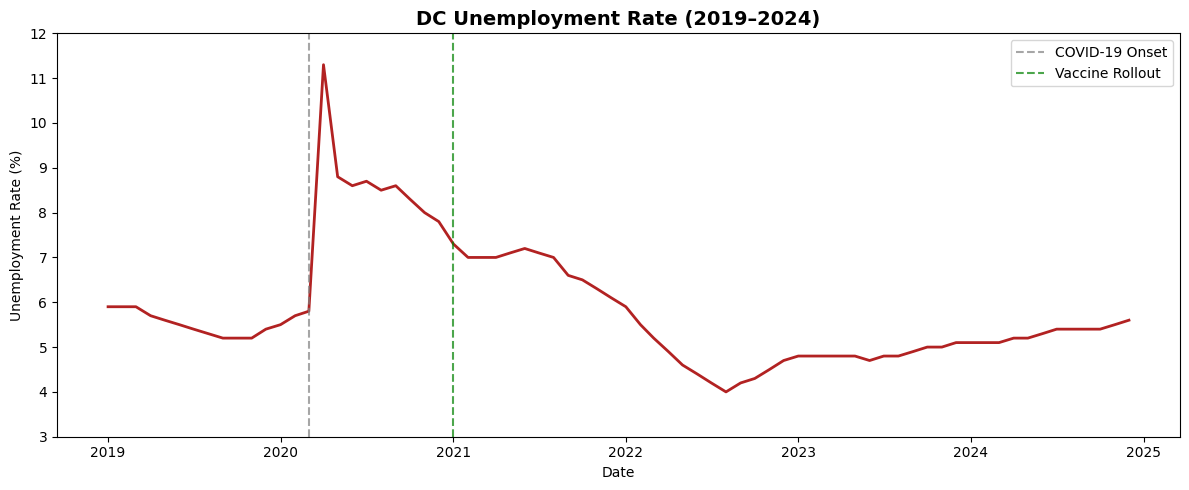

In [2]:
plt.figure(figsize=(12,5))
sns.lineplot(data=df, x='date', y='dc_unemployment_rate', color='firebrick', linewidth=2)
plt.axvline(pd.Timestamp('2020-03-01'), color='gray', linestyle='--', alpha=0.7, label='COVID-19 Onset')
plt.axvline(pd.Timestamp('2021-01-01'), color='green', linestyle='--', alpha=0.7, label='Vaccine Rollout')
plt.title('DC Unemployment Rate (2019–2024)', fontsize=14, fontweight='bold')
plt.xlabel('Date')
plt.ylabel('Unemployment Rate (%)')
plt.ylim(3, 12)
plt.legend(loc='upper right')
plt.tight_layout()
plt.savefig(BASE / 'figures/01_unemployment_trend.png', dpi=150, bbox_inches='tight')
plt.show()

## Chart 2: DC Employment Level Trend (2019–2024)
Source: BLS LAUS — Employment in thousands

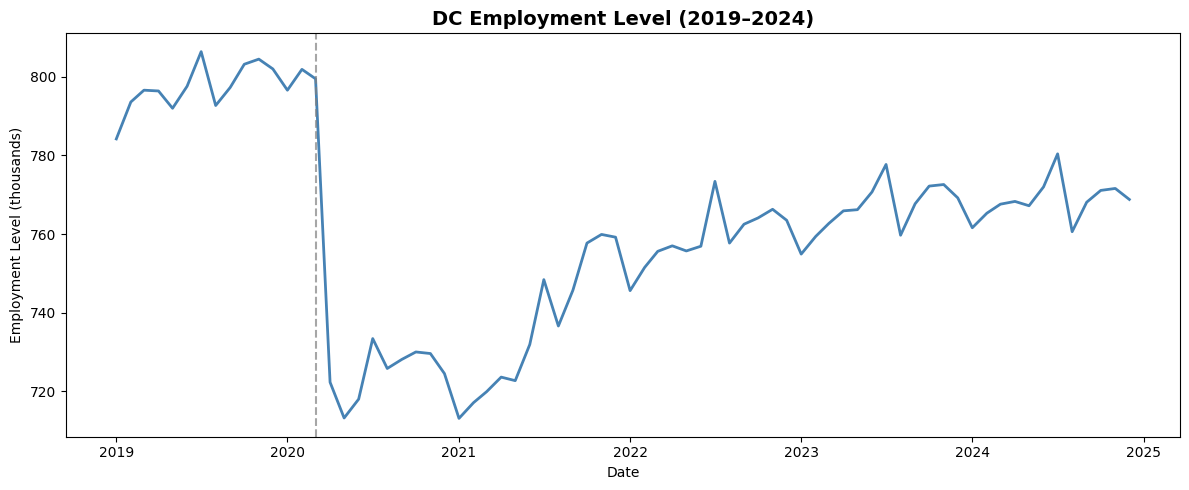

In [3]:
plt.figure(figsize=(12,5))
sns.lineplot(data=df, x='date', y='dc_employment_level', color='steelblue', linewidth=2)
plt.axvline(pd.Timestamp('2020-03-01'), color='gray', linestyle='--', alpha=0.7)
plt.title('DC Employment Level (2019–2024)', fontsize=14, fontweight='bold')
plt.xlabel('Date')
plt.ylabel('Employment Level (thousands)')
plt.tight_layout()
plt.savefig(BASE / 'figures/02_employment_trend.png', dpi=150, bbox_inches='tight')
plt.show()

## Chart 3: Dual-Axis — Unemployment Rate vs Employment Level
Source: BLS LAUS — Shows inverse correlation between the two metrics

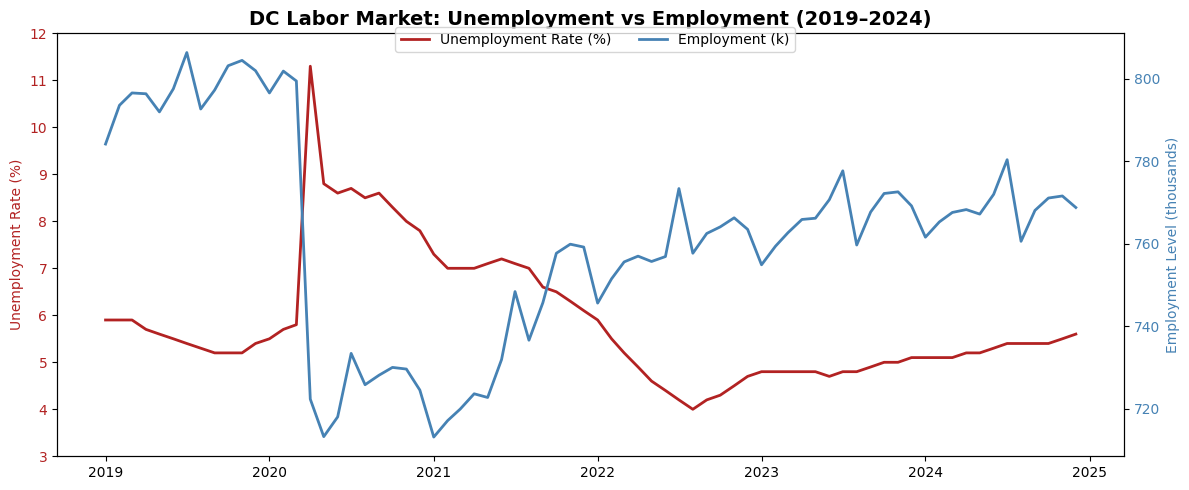

In [4]:
fig, ax1 = plt.subplots(figsize=(12,5))
ax1.plot(df['date'], df['dc_unemployment_rate'], color='firebrick', linewidth=2, label='Unemployment Rate (%)')
ax1.set_ylabel('Unemployment Rate (%)', color='firebrick')
ax1.tick_params(axis='y', labelcolor='firebrick')
ax1.set_ylim(3, 12)
ax2 = ax1.twinx()
ax2.plot(df['date'], df['dc_employment_level'], color='steelblue', linewidth=2, label='Employment (k)')
ax2.set_ylabel('Employment Level (thousands)', color='steelblue')
ax2.tick_params(axis='y', labelcolor='steelblue')
plt.title('DC Labor Market: Unemployment vs Employment (2019–2024)', fontsize=14, fontweight='bold')
fig.legend(loc='upper center', ncol=2, bbox_to_anchor=(0.5, 0.95))
plt.tight_layout()
plt.savefig(BASE / 'figures/03_dual_axis_labor.png', dpi=150, bbox_inches='tight')
plt.show()

## Chart 4: Year-over-Year Unemployment Rate by Month
Source: BLS LAUS — Compares seasonal patterns across years

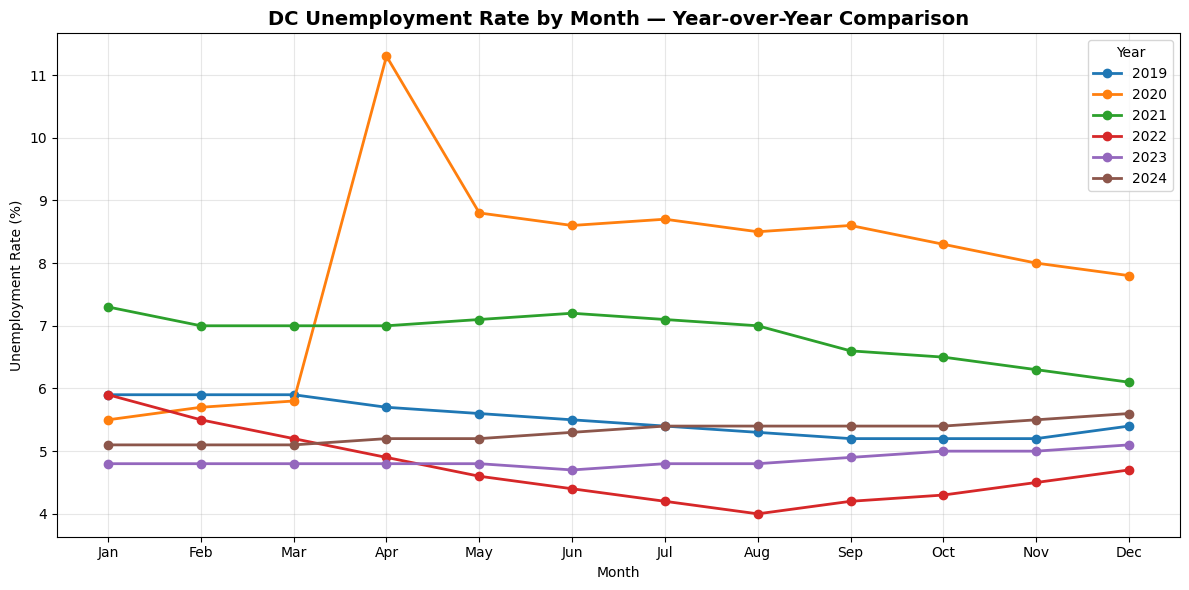

In [5]:
df['month'] = df['date'].dt.month
df['year_label'] = df['year'].astype(str)
pivot = df.pivot(index='month', columns='year_label', values='dc_unemployment_rate')

plt.figure(figsize=(12,6))
for year in pivot.columns:
    plt.plot(pivot.index, pivot[year], marker='o', label=year, linewidth=2)
plt.title('DC Unemployment Rate by Month — Year-over-Year Comparison', fontsize=14, fontweight='bold')
plt.xlabel('Month')
plt.ylabel('Unemployment Rate (%)')
plt.xticks(range(1,13), ['Jan','Feb','Mar','Apr','May','Jun','Jul','Aug','Sep','Oct','Nov','Dec'])
plt.legend(title='Year')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig(BASE / 'figures/04_yoy_unemployment.png', dpi=150, bbox_inches='tight')
plt.show()

## Chart 5: Post-2020 Recovery Trajectory
Source: BLS LAUS — Indexed to Jan 2020 = 100 to show relative recovery

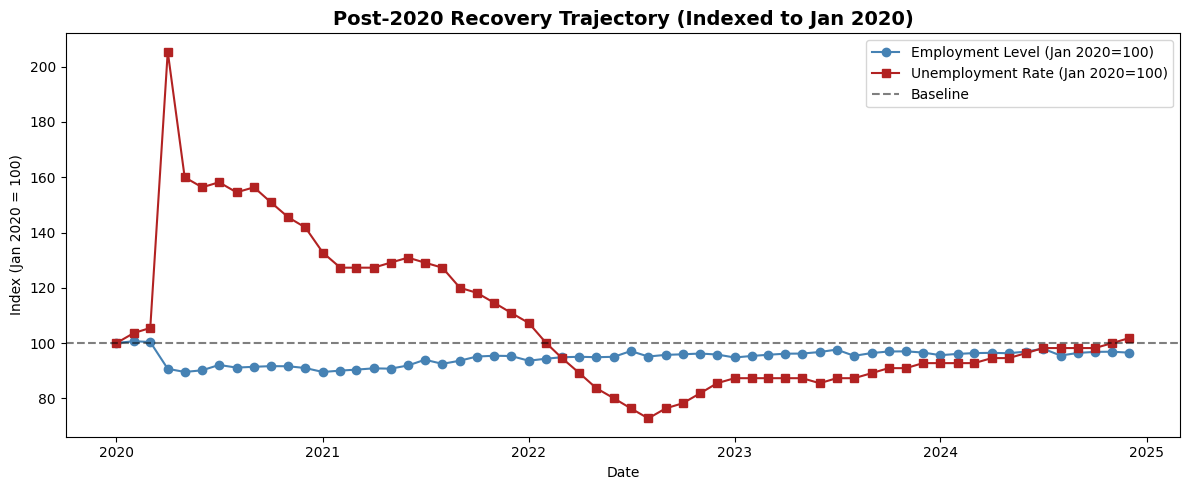

In [6]:
post2020 = df[df['date'] >= '2020-01-01'].copy()
base_emp = df[df['date'] == '2020-01-01']['dc_employment_level'].values[0]
base_ur = df[df['date'] == '2020-01-01']['dc_unemployment_rate'].values[0]
post2020['emp_index'] = (post2020['dc_employment_level'] / base_emp) * 100
post2020['ur_index'] = (post2020['dc_unemployment_rate'] / base_ur) * 100

plt.figure(figsize=(12,5))
plt.plot(post2020['date'], post2020['emp_index'], marker='o', label='Employment Level (Jan 2020=100)', color='steelblue')
plt.plot(post2020['date'], post2020['ur_index'], marker='s', label='Unemployment Rate (Jan 2020=100)', color='firebrick')
plt.axhline(100, color='black', linestyle='--', alpha=0.5, label='Baseline')
plt.title('Post-2020 Recovery Trajectory (Indexed to Jan 2020)', fontsize=14, fontweight='bold')
plt.xlabel('Date')
plt.ylabel('Index (Jan 2020 = 100)')
plt.legend()
plt.tight_layout()
plt.savefig(BASE / 'figures/05_recovery_indexed.png', dpi=150, bbox_inches='tight')
plt.show()

## Chart 6: COVID-19 Shock Detail (Mar–Jun 2020)
Source: BLS LAUS — The sharpest labor market disruption in the dataset

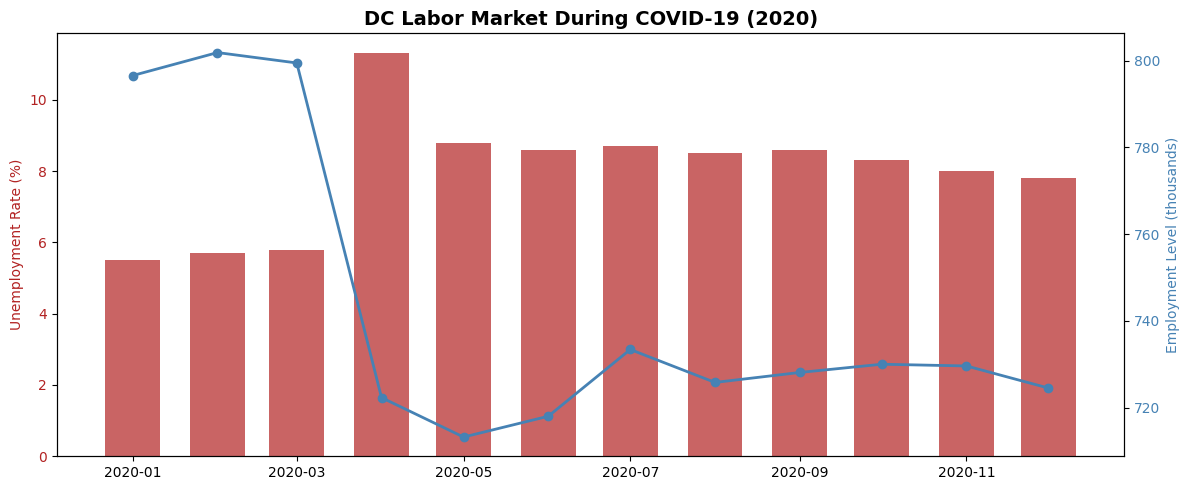

In [7]:
covid = df[(df['date'] >= '2020-01-01') & (df['date'] <= '2020-12-01')].copy()
fig, ax1 = plt.subplots(figsize=(12,5))
ax1.bar(covid['date'], covid['dc_unemployment_rate'], color='firebrick', alpha=0.7, width=20)
ax1.set_ylabel('Unemployment Rate (%)', color='firebrick')
ax1.tick_params(axis='y', labelcolor='firebrick')
ax2 = ax1.twinx()
ax2.plot(covid['date'], covid['dc_employment_level'], color='steelblue', marker='o', linewidth=2)
ax2.set_ylabel('Employment Level (thousands)', color='steelblue')
ax2.tick_params(axis='y', labelcolor='steelblue')
plt.title('DC Labor Market During COVID-19 (2020)', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig(BASE / 'figures/06_covid_shock.png', dpi=150, bbox_inches='tight')
plt.show()

## Chart 7: Annual Average Unemployment Rate
Source: BLS LAUS — Consolidated yearly view

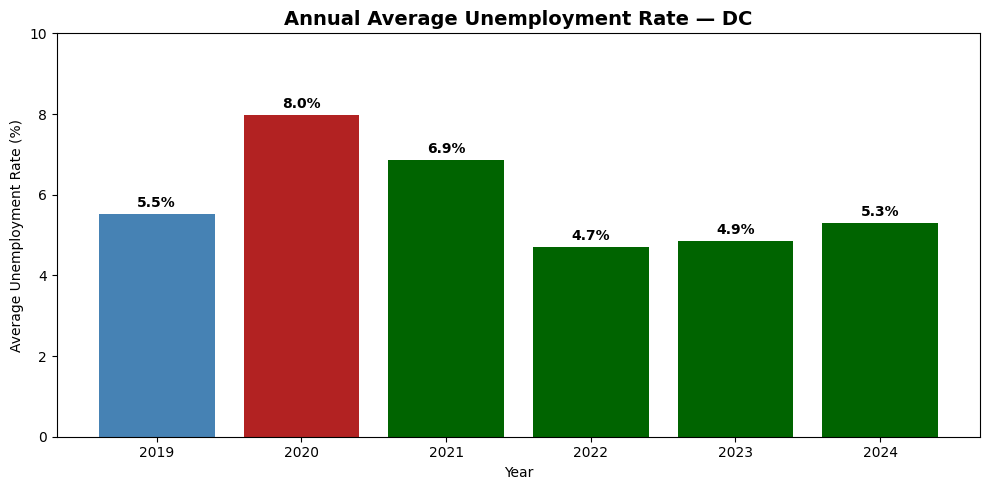

In [8]:
annual = df.groupby('year').agg({'dc_unemployment_rate':'mean','dc_employment_level':'mean'}).reset_index()
plt.figure(figsize=(10,5))
bars = plt.bar(annual['year'].astype(str), annual['dc_unemployment_rate'], color=['steelblue' if y < 2020 else 'firebrick' if y==2020 else 'darkgreen' for y in annual['year']])
plt.title('Annual Average Unemployment Rate — DC', fontsize=14, fontweight='bold')
plt.xlabel('Year')
plt.ylabel('Average Unemployment Rate (%)')
for bar, val in zip(bars, annual['dc_unemployment_rate']):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height()+0.1, f"{val:.1f}%", ha='center', va='bottom', fontweight='bold')
plt.ylim(0, 10)
plt.tight_layout()
plt.savefig(BASE / 'figures/07_annual_unemployment.png', dpi=150, bbox_inches='tight')
plt.show()

## Summary Statistics
Key labor market indicators derived from BLS data

In [9]:
summary = {
    'Total Records': len(df),
    'Date Range': f"{df['date'].min().date()} to {df['date'].max().date()}",
    'Peak Unemployment': f"{df['dc_unemployment_rate'].max():.1f}% (Apr 2020)",
    'Lowest Unemployment': f"{df['dc_unemployment_rate'].min():.1f}% (Aug 2022)",
    'Latest Unemployment': f"{df['dc_unemployment_rate'].iloc[-1]:.1f}% (Dec 2024)",
    'Employment Drop (Mar–Apr 2020)': f"{df[df['date']=='2020-03-01']['dc_employment_level'].values[0] - df[df['date']=='2020-04-01']['dc_employment_level'].values[0]:.1f}k",
    'Recovery to Pre-COVID': 'Employment still below Jan 2020 baseline as of Dec 2024' if df['dc_employment_level'].iloc[-1] < base_emp else 'Recovered above baseline',
}
for k, v in summary.items():
    print(f"{k}: {v}")

Total Records: 72
Date Range: 2019-01-01 to 2024-12-01
Peak Unemployment: 11.3% (Apr 2020)
Lowest Unemployment: 4.0% (Aug 2022)
Latest Unemployment: 5.6% (Dec 2024)
Employment Drop (Mar–Apr 2020): 77.2k
Recovery to Pre-COVID: Employment still below Jan 2020 baseline as of Dec 2024
